In [1]:
import pandas as pd
import easygui
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from numpy.random import random
from plotly.subplots import make_subplots

In [178]:
#color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#17becf', 
#    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#aec7e8', '#ffbb78',
#    '#98df8a', '#ff9896', '#c5b0d5', '#9edae5', '#c49c94', '#f7b6d2',
#    '#c7c7c7', '#dbdb8d', '#9ecae1', '#fdae6b', '#74c476', '#e6550d',
#    '#756bb1', '#31a354', '#3182bd', '#de2d26', '#6baed6', '#fd8d3c',
#    '#78c679', '#9e9ac8']

In [12]:
def load():
    global files
    files = easygui.fileopenbox(filetypes="*.csv", multiple=True)

### All plots

In [65]:
def plots():
    colors = ['#2c2ca0','#a02c2c','#2ca02c','#7f0eff',
          '#ff7f0e','#0e8eff','#da0074',
          '#8b4513','#556b2f','#c2185b',
          '#004a19','#00314a', '#7f00cc','#004dcc','#cc004d',]
    additional_colors = ['#ff1493', '#32cd32', '#8a2be2', '#ff4500',  
                     '#4682b4', '#b22222', '#228b22', '#9400d3',  
                     '#ffa500', '#20b2aa', '#ff00ff', '#dc143c',  
                     '#00ced1', '#9370db', '#708090', '#6a5acd']
    more_colors = ['#1e90ff', '#ff6347', '#2f4f4f', '#8b0000',  
               '#556b2f', '#483d8b', '#008080', '#b8860b',  
               '#4682b4', '#d2691e', '#5f9ea0', '#ff69b4',  
               '#4b0082', '#7cfc00', '#9932cc', '#ff8c00',  
               '#8fbc8f', '#dc143c', '#00ff7f', '#adff2f']
    color = colors + additional_colors + more_colors
    deltaFugureNames = [f'Приращение температуры от года к году {x.split('-')[1]}' for x in files]
    fig_max_min_ROWS = 2 #rows for maxmin plot
    fig_max_min = make_subplots(rows=fig_max_min_ROWS, cols=1,subplot_titles = ['График максимальных суточных температур',
                                                             'График минимальных суточных температур'], vertical_spacing=0.07)
    fig_delta_ROWS = len(files) #rows for delta plot
    fig_delta = make_subplots(rows=fig_delta_ROWS, cols=1,subplot_titles = deltaFugureNames, vertical_spacing=0.03)
    fig_season = go.Figure()
    
    for name, i, j in zip(files, range(len(color)), range(len(files))):
        csv = pd.read_csv(name)
        #maximum 
        fig_max_min.add_trace(go.Scatter(x=csv['Дата'], y=csv['max'], name=name.split('-')[1], line_shape='hv', 
                                    mode='lines+markers', marker_color=color[i], legendgroup=name.split('-')[1]), row = 1, col = 1)
        #minimum
        fig_max_min.add_trace(go.Scatter(x = csv['Дата'], y = csv['max'], name=name.split('-')[1], line_shape='hv',
                                    mode='lines+markers', marker_color=color[i], legendgroup=name.split('-')[1]), row = 2, col = 1) 
        #processing for plots
        csv['year'] = [x.strftime('%Y') for x in csv['Дата'].astype('datetime64[ns]')]
        csv['month'] = [x.strftime('%B') for x in csv['Дата'].astype('datetime64[ns]')]
        monthCategory = pd.CategoricalDtype(
            categories=["January", "February", "March", "April", "May", "June", 
                        "July", "August", "September", "October", "November", "December"],ordered=True)
        csv = csv.groupby(by=['year', "month"])[['max']].max().reset_index()
        csv= csv[(csv['month'] == 'June')|(csv['month'] == 'December')].drop(1).reset_index(drop=True)
        csv['month'] = csv['month'].astype(monthCategory)
        csv['season'] = ['winter' if 'December' in x else 'summer' for x in csv['month']]
        csv = csv.sort_values(['year', 'month']).reset_index(drop=True)
        csv['year'] = [x + '-' + y for x, y in zip(csv['year'], csv['month'])]
        csv.rename(columns = {'year':'date'}, inplace = True)
        csv.drop(columns = ['month'], inplace = True)
        csv['date'] = [x.strftime('%Y-%B') for x in csv['date'].astype('datetime64[ns]')]
        #seasom maximum plots
        summer = csv[csv['season'].isin(['summer'])].reset_index().drop(['index', 'season'], axis = 1)
        winter = csv[csv['season'].isin(['winter'])].reset_index().drop(['index', 'season'], axis = 1)
        fig_season.add_trace(go.Bar(x=summer['date'].astype('datetime64[ns]'), y=summer['max'], 
                                            name=f'{name.split('-')[1]} Лето', marker_color=color[i]))#, row = 1, col = 1)
        fig_season.add_trace(go.Bar(x=winter['date'].astype('datetime64[ns]'), y=winter['max'], 
                                            name=f'{name.split('-')[1]} Зима', marker_color=color[i]))#, row = 1, col = 1)
        year_summer = []
        year_winter = []
        delta_summer = []
        delta_winter = []
        #season delta plots
        for x in range(len(summer['date'])):
            if x < len(summer['date']) - 1:
                year_summer.append(summer['date'].iloc[x+1].split('-')[0]+'-'+ summer['date'].iloc[x].split('-')[0])
                delta_summer.append(summer['max'].iloc[x+1] - summer['max'].iloc[x])
        for x in range(len(winter['date'])):
            if x < len(winter['date']) - 1:
                year_winter.append(winter['date'].iloc[x+1].split('-')[0]+'-'+ winter['date'].iloc[x].split('-')[0])        
                delta_winter.append(winter['max'].iloc[x+1] - winter['max'].iloc[x])
        summer['delta_year'] = year_summer + [np.nan]
        summer['delta_t'] = delta_summer+ [np.nan]
        winter['delta_year'] = year_winter + [np.nan]
        winter['delta_t'] = delta_winter+ [np.nan]
        
        fig_delta.add_trace(go.Bar(x=summer['delta_year'], y=summer['delta_t'], 
                                            name=f'{name.split('-')[1]} Лето', marker_color='red'), row = j+1, col = 1)
        fig_delta.add_trace(go.Bar(x=winter['delta_year'], y=winter['delta_t'], 
                                            name=f'{name.split('-')[1]} Зима', marker_color='blue'), row = j+1, col = 1)
    #PLOTS SETTINGS
    for x in range(fig_delta_ROWS):
        fig_delta.update_xaxes(title_text="Дата", tickangle=-45, row=x, col=1)  
        fig_delta.update_yaxes(title_text="Δ, °C", row=x, col=1)
    for x in range(fig_max_min_ROWS):
        fig_max_min.update_xaxes(title_text="Дата", tickangle=-45, row=x, col=1)  
        fig_max_min.update_yaxes(title_text="Температура, °C", row=x, col=1)  
    #resizing
    fig_max_min.update_layout(width=1900,  height=2000, legend=dict(groupclick='togglegroup'))
    fig_delta.update_layout(width=1900,  height=4000)
    fig_season.update_layout(title="График максимальных сезонных температур",
        xaxis=dict(title="Дата", rangeslider=dict(visible=False)),
        yaxis=dict(title="Температура", fixedrange=False))
    #saving
    seen = set()
    fig_max_min.for_each_trace(
        lambda t: t.update(showlegend=False) if t.name in seen or seen.add(t.name) else None)
    fig_max_min.write_html(f"{files[0].split('-')[0]}MaxMin.html") 
    fig_delta.write_html(f"{files[0].split('-')[0]}delta.html") 
    fig_season.write_html(f"{files[0].split('-')[0]}Season.html") 

In [ ]:
plots()

### max values by every month plot 

In [183]:
maxByMonth = defaultdict(list)
def monthlyMax():
    colors = ['#2c2ca0','#a02c2c','#2ca02c','#7f0eff',
          '#ff7f0e','#0e8eff','#da0074',
          '#8b4513','#556b2f','#c2185b',
          '#004a19','#00314a', '#7f00cc','#004dcc','#cc004d',]
    additional_colors = ['#ff1493', '#32cd32', '#8a2be2', '#ff4500',  
                     '#4682b4', '#b22222', '#228b22', '#9400d3',  
                     '#ffa500', '#20b2aa', '#ff00ff', '#dc143c',  
                     '#00ced1', '#9370db', '#708090', '#6a5acd']
    more_colors = ['#1e90ff', '#ff6347', '#2f4f4f', '#8b0000',  
               '#556b2f', '#483d8b', '#008080', '#b8860b',  
               '#4682b4', '#d2691e', '#5f9ea0', '#ff69b4',  
               '#4b0082', '#7cfc00', '#9932cc', '#ff8c00',  
               '#8fbc8f', '#dc143c', '#00ff7f', '#adff2f']
    color = colors + additional_colors + more_colors
    fig = go.Figure()
    for name, i in zip(files, range(len(files))):
        csv = pd.read_csv(name)
        csv['year'] = [x.strftime('%Y') for x in csv['Дата'].astype('datetime64[ns]')]
        csv['month'] = [x.strftime('%B') for x in csv['Дата'].astype('datetime64[ns]')]
        monthCategory = pd.CategoricalDtype(
            categories=["January", "February", "March", "April", "May", "June", 
                        "July", "August", "September", "October", "November", "December"],ordered=True)
        csv['month'] = csv['month'].astype(monthCategory)
        csv = csv.groupby(by=['year', "month"], observed = True)[['max']].max().reset_index()
        csv['date'] = [(x+'-'+y) for x,y in zip(csv['year'], csv['month'])]
        csv['date'] = [x.strftime('%Y-%B') for x in csv['date'].astype('datetime64[ns]')]
        maxByMonth[f'{name.split('-')[1]}'].append(csv)
        fig.add_trace(go.Scatter(x = csv['date'], y = csv['max'], mode = 'lines+markers', line_shape='hv',
                                name = f'{name.split('-')[1]}', marker_color = color[i]))
    fig.update_layout(title = 'Ежемесячный температурный максимум')
    fig.update_xaxes(title_text="Дата", tickangle=-45)  
    fig.update_yaxes(title_text="Температура, °C")  
    fig.write_html(f"{files[0].split('-')[0]}Montly max.html")

In [184]:
monthlyMax()

### winter and summer values plot

In [42]:
def winSum():
    colors = ['#2c2ca0','#a02c2c','#2ca02c','#7f0eff',
          '#ff7f0e','#0e8eff','#da0074',
          '#8b4513','#556b2f','#c2185b',
          '#004a19','#00314a', '#7f00cc','#004dcc','#cc004d',]
    additional_colors = ['#ff1493', '#32cd32', '#8a2be2', '#ff4500',  
                     '#4682b4', '#b22222', '#228b22', '#9400d3',  
                     '#ffa500', '#20b2aa', '#ff00ff', '#dc143c',  
                     '#00ced1', '#9370db', '#708090', '#6a5acd']
    more_colors = ['#1e90ff', '#ff6347', '#2f4f4f', '#8b0000',  
               '#556b2f', '#483d8b', '#008080', '#b8860b',  
               '#4682b4', '#d2691e', '#5f9ea0', '#ff69b4',  
               '#4b0082', '#7cfc00', '#9932cc', '#ff8c00',  
               '#8fbc8f', '#dc143c', '#00ff7f', '#adff2f']
    color = colors + additional_colors + more_colors
    fig = go.Figure()
    for name, i, j in zip(files, range(len(color)), range(len(files))):
        csv = pd.read_csv(name)
        csv['year'] = [x.strftime('%Y') for x in csv['Дата'].astype('datetime64[ns]')]
        csv['month'] = [x.strftime('%B') for x in csv['Дата'].astype('datetime64[ns]')]
        monthCategory = pd.CategoricalDtype(
            categories=["January", "February", "March", "April", "May", "June", 
                        "July", "August", "September", "October", "November", "December"],ordered=True)
        csv = csv.groupby(by=['year', "month"])[['max']].max().reset_index()
        csv= csv[(csv['month'] == 'June')|(csv['month'] == 'December')].drop(1).reset_index(drop=True)
        csv['month'] = csv['month'].astype(monthCategory)
        csv['season'] = ['winter' if 'December' in x else 'summer' for x in csv['month']]
        csv = csv.sort_values(['year', 'month']).reset_index(drop=True)
        csv['year'] = [x + '-' + y for x, y in zip(csv['year'], csv['month'])]
        csv.rename(columns = {'year':'date'}, inplace = True)
        csv.drop(columns = ['month'], inplace = True)
        csv['date'] = [x.strftime('%Y-%B') for x in csv['date'].astype('datetime64[ns]')]
        fig.add_trace(go.Scatter(x = csv['date'], y = csv['max'], mode = 'lines + markers', #line_shape='hv',
                                name = f'{name.split('-')[1]}', marker_color = color[i]))
    fig.update_xaxes(title_text="Дата", tickangle=-45)  
    fig.update_yaxes(title_text="Температура, °C")
    fig.update_layout(title="График максимальных сезонных температур")
    fig.write_html(f"{files[0].split('-')[0]}MaxSeason.html") 

In [46]:
winSum()

In [19]:
load()

### delta plot

In [49]:
def delta():
    colors = ['#2c2ca0','#a02c2c','#2ca02c','#7f0eff',
          '#ff7f0e','#0e8eff','#da0074',
          '#8b4513','#556b2f','#c2185b',
          '#004a19','#00314a', '#7f00cc','#004dcc','#cc004d',]
    additional_colors = ['#ff1493', '#32cd32', '#8a2be2', '#ff4500',  
                     '#4682b4', '#b22222', '#228b22', '#9400d3',  
                     '#ffa500', '#20b2aa', '#ff00ff', '#dc143c',  
                     '#00ced1', '#9370db', '#708090', '#6a5acd']
    more_colors = ['#1e90ff', '#ff6347', '#2f4f4f', '#8b0000',  
               '#556b2f', '#483d8b', '#008080', '#b8860b',  
               '#4682b4', '#d2691e', '#5f9ea0', '#ff69b4',  
               '#4b0082', '#7cfc00', '#9932cc', '#ff8c00',  
               '#8fbc8f', '#dc143c', '#00ff7f', '#adff2f']
    color = colors + additional_colors + more_colors
    fig = go.Figure()
    for name, i, j in zip(files, range(len(color)), range(len(files))):
        csv = pd.read_csv(name)
        csv['year'] = [x.strftime('%Y') for x in csv['Дата'].astype('datetime64[ns]')]
        csv['month'] = [x.strftime('%B') for x in csv['Дата'].astype('datetime64[ns]')]
        csv = csv.groupby(by=['year'])[['max']].max().reset_index()

        year = []
        delta = []

        for x in range(len(csv['year'])):
            if x < len(csv['year']) - 1:
                year.append(csv['year'].iloc[x+1].split('-')[0]+'-'+ csv['year'].iloc[x].split('-')[0])
                delta.append(csv['max'].iloc[x+1] - csv['max'].iloc[x])
        csv_delta = pd.DataFrame()
        csv_delta['delta_year'] = year
        csv_delta['delta_temperature'] = delta
        
        fig.add_trace(go.Scatter(x = csv_delta['delta_year'], y = csv_delta['delta_temperature'], mode = 'lines + markers', #line_shape='hv',
                                name = f'{name.split('-')[1]}', marker_color = color[i]))
    fig.update_xaxes(title_text="Дата", tickangle=-45)  
    fig.update_yaxes(title_text="Δ, °C")
    fig.update_layout(title="График изменения температур")
    fig.write_html(f"{files[0].split('-')[0]}deltaYear.html") 

In [50]:
delta()

### Creating Monthly csv

In [16]:
files = easygui.fileopenbox(filetypes="*.csv", multiple=True)
for name, i in zip(files, range(len(files))):
    csv = pd.read_csv(name)
    csv['year'] = [x.strftime('%Y') for x in csv['Дата'].astype('datetime64[ns]')]
    csv['month'] = [x.strftime('%B') for x in csv['Дата'].astype('datetime64[ns]')]
    monthCategory = pd.CategoricalDtype(
        categories=["January", "February", "March", "April", "May", "June", 
                    "July", "August", "September", "October", "November", "December"],ordered=True)
    csv['month'] = csv['month'].astype(monthCategory)
    csv = csv.groupby(by=['year', "month"], observed = True)[['max']].max().reset_index()
    csv['date'] = [(x+'-'+y) for x,y in zip(csv['year'], csv['month'])]
    csv['date'] = [x.strftime('%Y-%B') for x in csv['date'].astype('datetime64[ns]')]
    csv.to_csv(f'data for ML\\-{name.split('-')[1]}-.csv', index = False)

TypeError: object of type 'NoneType' has no len()

### Creating Q by month

In [17]:
files = easygui.fileopenbox(filetypes="*.csv", multiple=True)

In [49]:
txt = pd.read_csv(files[0], sep = '\t', header = 2)
txt.drop(txt.columns[0], axis = 1, inplace = True)
txt.rename(columns = {'Дата Время         ':'Дата и Время'}, inplace = True)
txt['Дата'] = txt['Дата и Время'].apply(lambda x:x.split(' ')[0])
txt['Значение'] = txt['Значение'].replace(',','.', regex=True).astype('float64')
txt['Дата'] = pd.to_datetime(txt['Дата'], dayfirst=True).dt.date
txt['Дата и Время'] = pd.to_datetime(txt['Дата и Время'], format= "%d.%m.%Y %H:%M:%S")

In [50]:
txt['year'] = [x.strftime('%Y') for x in txt['Дата'].astype('datetime64[ns]')]
txt['month'] = [x.strftime('%B') for x in txt['Дата'].astype('datetime64[ns]')]

In [51]:
monthCategory = pd.CategoricalDtype(
    categories=["January", "February", "March", "April", "May", "June", 
                "July", "August", "September", "October", "November", "December"],ordered=True)

txt['month'] = txt['month'].astype(monthCategory)
txt = txt.groupby(by=['year', "month"], observed = True)[['Значение']].max().reset_index()
txt['date'] = [(x+'-'+y) for x,y in zip(txt['year'], txt['month'])]
txt['date'] = [x.strftime('%Y-%B') for x in txt['date'].astype('datetime64[ns]')]

In [94]:
txt['Значение'] = txt['Значение']/60

In [55]:
txt.iloc[0:125]

,year,month,Значение,date
0,2015,January,-1173.8,2015-January
1,2015,February,-601.2,2015-February
2,2015,March,97.0,2015-March
3,2015,April,740.0,2015-April
4,2015,May,1228.5,2015-May
...,...,...,...,...
120,2025,January,-1164.1,2025-January
121,2025,February,-587.3,2025-February
122,2025,March,65.2,2025-March
123,2025,April,752.4,2025-April


In [57]:
files = easygui.fileopenbox(multiple=True)

In [58]:
As = pd.read_excel(files[0], sheet_name = 'As')

In [62]:
As.iloc[:125].columns

Index(['Дата', ' Значение'], dtype='object')

In [114]:
SouthPanel = pd.DataFrame()
SouthPanel['date'] = txt['date'].iloc[0:125]
SouthPanel['max'] = [1404.5*4.89*x*np.sin(np.radians(y)) for x, y in zip(As.iloc[:125][' Значение'],txt.iloc[0:125]['Значение'])]

In [113]:
NorthPanel = pd.DataFrame()
NorthPanel['date'] = txt['date'].iloc[0:125]
NorthPanel['max'] = [1337.8*4.93*x*np.sin(np.radians(y/-1)) for x, y in zip(As.iloc[:125][' Значение'],txt.iloc[0:125]['Значение'])]

In [101]:
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.10)
fig.add_trace(go.Scatter(x = SouthPanel['date'], y = SouthPanel['max'], mode = 'lines + markers', #line_shape='hv',
                        name = 'Южная Панель'), row = 1, col = 1)

fig.add_trace(go.Scatter(x = NorthPanel['date'], y = NorthPanel['max'], mode = 'lines + markers', #line_shape='hv',
                        name = 'Северная Панель'), row = 2, col = 1)



fig.update_xaxes(title_text="Дата", tickangle=-45, row=1, col=1)  
fig.update_yaxes(title_text="Поглощение солнечного излучения, Вт", row=1, col=1)

fig.update_xaxes(title_text="Дата", tickangle=-45, row=2, col=1)  
fig.update_yaxes(title_text="Поглощение солнечного излучения, Вт", row=2, col=1)


fig.update_layout(width=1900,  height=1500)

fig.update_layout(title="Поглощенный тепловой поток")
fig.write_html(f"Q.html") 

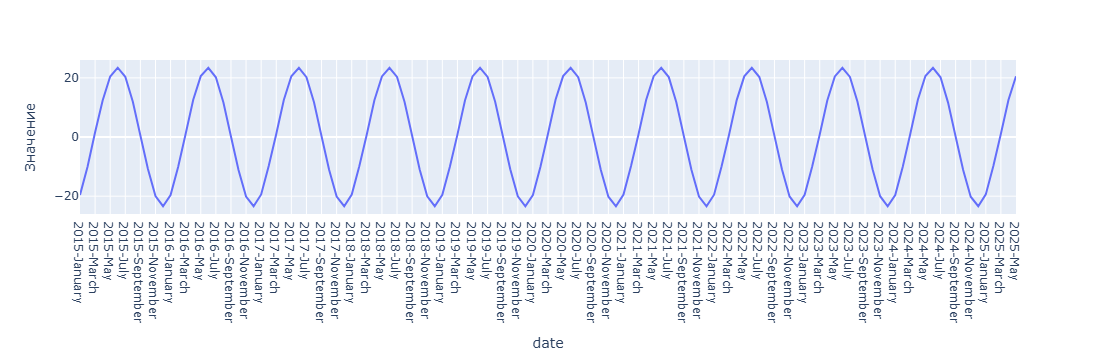

In [102]:
px.line(data_frame = txt.iloc[0:125], x = 'date', y = 'Значение')

In [107]:
NorthPanel.to_csv('NorthPanel.csv', index = False)

In [111]:
txt.iloc[:125]

,year,month,Значение,date
0,2015,January,-19.563333,2015-January
1,2015,February,-10.020000,2015-February
2,2015,March,1.616667,2015-March
3,2015,April,12.333333,2015-April
4,2015,May,20.475000,2015-May
...,...,...,...,...
120,2025,January,-19.401667,2025-January
121,2025,February,-9.788333,2025-February
122,2025,March,1.086667,2025-March
123,2025,April,12.540000,2025-April


### Расчет угла падения 

In [143]:
list(As['Дата'].astype('str'))[0]

'2015-01-22'

In [144]:
f"{list(As['Дата'].astype('str'))[0]}T00:00:00"

'2015-01-22T00:00:00'

In [6]:
len(pd.date_range(start='2015-01-01', end='2029-04-29', freq='D'))

3772

In [7]:
# Требует: astropy
from astropy.time import Time
from astropy.coordinates import get_sun, EarthLocation, ITRS
import numpy as np

from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None

tetta_north = []
tetta_south = []
    # вход
for x in list(pd.date_range(start='2015-01-01', end='2029-04-29', freq='D').astype('str')):
    lambda_deg = 58.5
    t = Time(f"{x}T00:00:00", scale='utc')   # замените на нужную дату/время UTC
    
    # 1) положение Солнца в GCRS / трансформируем в ITRS (приближенно ECEF)
    sun_gcrs = get_sun(t)
    sun_itrs = sun_gcrs.transform_to(ITRS(obstime=t))
    s_vec = np.array([sun_itrs.x.value, sun_itrs.y.value, sun_itrs.z.value])
    s_hat = s_vec / np.linalg.norm(s_vec)
    
    # 2) радиальный вектор спутника в ECEF (единичный)
    lam = np.deg2rad(lambda_deg)
    r_hat = np.array([np.cos(lam), np.sin(lam), 0.0])
    
    # 3) локальный север (проекция Z на плоскость, ортогональную r_hat)
    k = np.array([0.0, 0.0, 1.0])
    n_north = k - np.dot(k, r_hat)*r_hat
    n_north = n_north / np.linalg.norm(n_north)
    n_south = -n_north
    
    # 4) углы
    alpha_north = np.degrees(np.arccos(np.clip(np.dot(n_north, s_hat), -1.0, 1.0)))
    alpha_south = np.degrees(np.arccos(np.clip(np.dot(n_south, s_hat), -1.0, 1.0)))
    
    tetta_north.append(90 - alpha_north)
    tetta_south.append(90 - alpha_south)


C:\Users\sadykpayev\AppData\Local\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\sadykpayev\AppData\Local\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\sadykpayev\AppData\Local\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
C:\Users\sadykpayev\AppData\Local\anaconda3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [29]:
excel_file = 'C:\\Users\\sadykpayev\\Desktop\\Джуниор\\К3\\СТР\\Моделирование СТР в случае отказа двух ЖК\\data for ML\\General\\As.xlsx'
writer = pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='overlay')
pd.DataFrame(data = np.array([tetta_north,tetta_south]).T, columns = ['north', 'south']).to_excel(writer, sheet_name='Psi', index=False) 
writer.close()

In [27]:
pd.DataFrame(data = np.array([tetta_north,tetta_south]).T, columns = ['north', 'south'])

,north,south
0,-23.040573,23.040573
1,-22.958555,22.958555
2,-22.868914,22.868914
3,-22.771694,22.771694
4,-22.666941,22.666941
...,...,...
5228,13.214006,-13.214006
5229,13.537648,-13.537648
5230,13.857565,-13.857565
5231,14.173679,-14.173679


In [132]:
90 - alpha_north, 90 - alpha_south

(-23.43442003424869, 23.434420034248674)

In [149]:
psiAlpha = pd.DataFrame()
psiAlpha['date'] = As['Дата']
psiAlpha['north'] = tetta_north
psiAlpha['south'] = tetta_south

In [150]:
psiAlpha

,date,north,south
0,2015-01-22,-19.794525,19.794525
1,2015-02-22,-10.390448,10.390448
2,2015-03-22,0.415678,-0.415678
3,2015-04-22,12.013638,-12.013638
4,2015-05-22,20.274775,-20.274775
...,...,...,...
167,2028-12-22,-23.434191,23.434191
168,2029-01-22,-19.656216,19.656216
169,2029-02-22,-10.168208,10.168208
170,2029-03-22,0.657917,-0.657917


In [157]:
SouthPanelAll = pd.DataFrame()
SouthPanelAll['date'] = psiAlpha['date']
SouthPanelAll['max'] = [1404.5*4.89*x*np.sin(np.radians(y)) for x, y in zip(As[' Значение'],psiAlpha['north'])]

In [158]:
NorthPanelAll = pd.DataFrame()
NorthPanelAll['date'] = psiAlpha['date']
NorthPanelAll['max'] = [1337.8*4.93*x*np.sin(np.radians(y)) for x, y in zip(As[' Значение'],psiAlpha['south'])]

In [163]:
NorthPanelAll.to_csv('NorthPanelAll.csv', index = False)

In [164]:
NorthPanelAll

,date,max
0,2015-01-22,310.456987
1,2015-02-22,171.241307
2,2015-03-22,-7.102638
3,2015-04-22,-210.585490
4,2015-05-22,-359.238679
...,...,...
167,2028-12-22,738.250825
168,2029-01-22,625.173198
169,2029-02-22,328.501419
170,2029-03-22,-21.389814
